In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

In [57]:
dims = []
voxelsizes = []
bytes_per_pixel = 0

with open('CASToR_files/MovingSourceRun_LtoR_OptimizedV2_OV_T1_7200s_TrigOn_coinc_it1.hdr', 'r') as f:
    for line in f:
        if '!matrix size' in line:
            dims.append(int(line[line.index(':=') + 3:-1]))
        elif 'scaling factor' in line:
            voxelsizes.append(float(line[line.index(':=') + 3:-1]))
        elif '!number of bytes per pixel' in line:
            bytes_per_pixel = int(line[line.index(':=') + 3:-1])




In [58]:
dims, voxelsizes, bytes_per_pixel

([180, 180, 80], [1.5, 1.5, 1.5], 4)

In [63]:
img_path = 'CASToR_files/MovingSourceRun_LtoR_OptimizedV2_OV_T1_7200s_TrigOn_coinc_it1.img'
with open(img_path, 'rb') as f:
    img_data = np.fromfile(f, dtype=np.dtype(f'uint{bytes_per_pixel * 8}')).astype(np.float32).reshape(dims)

In [101]:
sorted = np.sort(img_data.flatten())
maxval = sorted[-1]
top1 = sorted[int(0.999 * len(sorted))]
top100 = sorted[int(0.9999 * len(sorted))]

In [102]:
above = sorted[int(0.999 * len(sorted)):int(0.9999 * len(sorted))]
above = above / maxval
below = sorted[:int(0.999 * len(sorted))]
below = below / maxval
colormax = sorted[int(0.9999 * len(sorted)):] / maxval


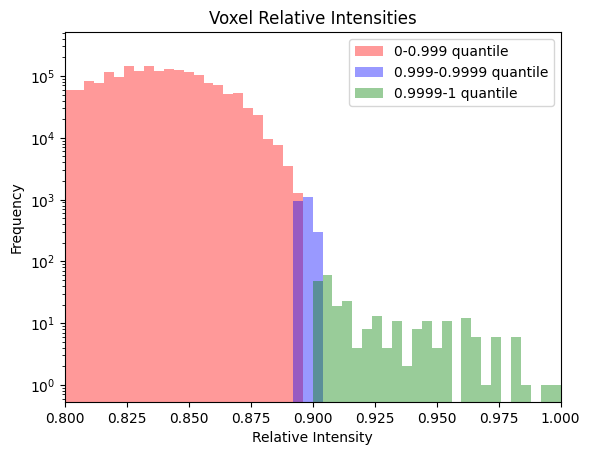

In [108]:
hist, bin_edges = np.histogram(img_data / maxval, bins=250)
plt.hist(below, bin_edges, color = 'red', alpha = 0.4, label = '0-0.999 quantile')
plt.hist(above, bin_edges, color = 'blue', alpha = 0.4, label = '0.999-0.9999 quantile')
plt.hist(colormax, bin_edges, color = 'green', alpha = 0.4, label = '0.9999-1 quantile')
#plt.bar(bin_edges[:-1], hist, width=np.diff(bin_edges), align='edge', color = 'blue', alpha = 0.4)
plt.title("Voxel Relative Intensities")
plt.xlabel("Relative Intensity")
plt.ylabel("Frequency")
plt.xlim(0.8, 1.0)
plt.yscale('log')
plt.legend()
plt.show()


In [ ]:
`x0 = (-0.5 * (dims[0] - 1) * voxelsizes[0])
y0 = (-0.5 * (dims[1] - 1) * voxelsizes[1])
z0 = (-0.5 * (dims[2] - 1) * voxelsizes[2])
for x in range(dims[0]):
    for y in range(dims[1]):
        for z in range(dims[2]):
            if img_data[x, y, z] > 0:
                pass
print(x0, y0, z0)
`

-134.25 -134.25 -59.25


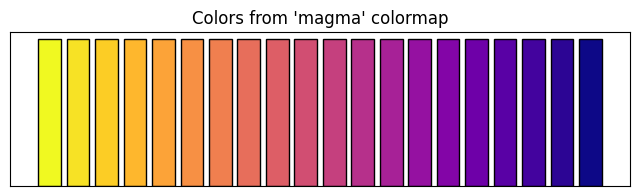

In [62]:
import matplotlib.pyplot as plt
import matplotlib.colors


cmap = plt.get_cmap('plasma')
# Example list of color values (replace with your own if needed)
color_values = np.linspace(1, 0, 20)
colors = cmap(color_values)  # RGBA colors

fig, ax = plt.subplots(figsize=(8, 2))
for i, color in enumerate(colors):
    ax.bar(i, 1, color=color, edgecolor='k')
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("Colors from 'magma' colormap")
plt.show()


In [119]:
cmap = plt.get_cmap('viridis')
print(cmap(0.0))

(np.float64(0.267004), np.float64(0.004874), np.float64(0.329415), np.float64(1.0))


In [16]:
print(np.logspace(np.log10(1), np.log10(100), 10))

[  1.           1.66810054   2.7825594    4.64158883   7.74263683
  12.91549665  21.5443469   35.93813664  59.94842503 100.        ]


In [136]:
import pyvista as pv

pl = pv.Plotter(off_screen=True, window_size=(512, 512))

mesh = pv.Sphere()
pl.add_mesh(mesh)
pl.set_background("white")

pl.open_gif("/home/kale-chen/Downloads/sphere_rotation.gif", fps=20)  # <-- key step

pl.camera_position = "iso"

# Rotate camera and capture frames
n_frames = 120
for _ in range(n_frames):
    angle = 360 * _ / n_frames
    pl.camera.azimuth = angle
    pl.render()
    pl.write_frame()

pl.close()


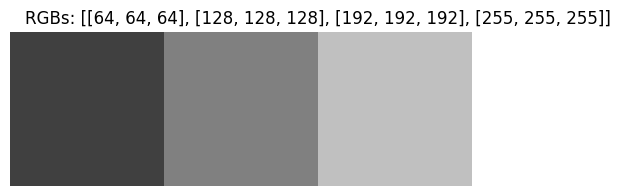

In [48]:
from vtpgenerator_utils import get_color
import matplotlib.pyplot as plt
import numpy as np

colors = []
for i in range(4):
    colors.append(get_color((i+1) / 4, 'gist_gray'))

plt.figure(figsize=(len(colors) * 2, 2))
# Create a 1-row image, shape (1, N, 3)
color_array = np.array(colors, dtype=np.uint8).reshape(1, len(colors), 3)
plt.imshow(color_array)
plt.axis('off')
plt.title(f"RGBs: {colors}")
plt.show()



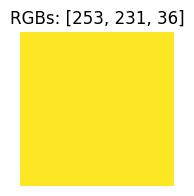

In [18]:
import matplotlib.pyplot as plt
import numpy as np

color = [253, 231, 36]
# Create a 1-row image, shape (1, N, 3)
plt.figure(figsize=(2, 2))
color_array = np.array(color, dtype=np.uint8).reshape(1, 1, 3)
plt.imshow(color_array)
plt.axis('off')
plt.title(f"RGBs: {color}")
plt.show()



In [2]:
import pydicom

dcm = pydicom.dcmread('/home/kale-chen/Documents/PET/TPPTvis/zz20260319/CT1.3.12.2.1107.5.1.4.83355.30000026031913575737000011119.dcm')
print(dcm)





Dataset.file_meta -------------------------------
(0002,0000) File Meta Information Group Length  UL: 286
(0002,0001) File Meta Information Version       OB: b'\x00\x01'
(0002,0002) Media Storage SOP Class UID         UI: CT Image Storage
(0002,0003) Media Storage SOP Instance UID      UI: 1.3.12.2.1107.5.1.4.83355.30000026031913575737000011119
(0002,0010) Transfer Syntax UID                 UI: Implicit VR Little Endian
(0002,0012) Implementation Class UID            UI: 1.2.826.0.1.3680043.1.2.100.8.40.1101.0
(0002,0013) Implementation Version Name         SH: 'DicomObjects.NET'
(0002,0100) Private Information Creator UID     UI: 1.2.826.0.1.3680043.1.2.100.8.40.1101.0
(0002,0102) Private Information                 OB: b'DicomObjects.NET'
-------------------------------------------------
(0008,0005) Specific Character Set              CS: 'ISO_IR 100'
(0008,0008) Image Type                          CS: ['ORIGINAL', 'PRIMARY', 'AXIAL', 'CT_SOM5 SPI']
(0008,0016) SOP Class UID        

In [25]:
img = dcm.pixel_array.astype(np.float32)
#img = img * dcm.RescaleSlope + dcm.RescaleIntercept

In [27]:
print(img.shape)

(512, 512)


In [26]:
print(np.unique(img))

[0.000e+00 1.000e+00 1.400e+01 1.500e+01 1.600e+01 1.700e+01 1.800e+01
 1.900e+01 2.000e+01 2.100e+01 2.200e+01 2.300e+01 2.400e+01 2.500e+01
 2.600e+01 2.700e+01 2.800e+01 2.900e+01 3.000e+01 3.100e+01 3.200e+01
 3.300e+01 3.400e+01 3.500e+01 3.600e+01 3.700e+01 3.800e+01 3.900e+01
 4.000e+01 4.100e+01 4.200e+01 4.300e+01 4.400e+01 4.500e+01 4.600e+01
 4.700e+01 4.800e+01 4.900e+01 5.000e+01 5.100e+01 5.200e+01 5.300e+01
 5.400e+01 5.500e+01 5.600e+01 5.700e+01 5.800e+01 5.900e+01 6.000e+01
 6.100e+01 6.200e+01 6.300e+01 6.400e+01 6.500e+01 6.600e+01 6.700e+01
 6.800e+01 6.900e+01 7.000e+01 7.100e+01 7.200e+01 7.300e+01 7.400e+01
 7.500e+01 7.600e+01 7.700e+01 7.800e+01 7.900e+01 8.000e+01 8.100e+01
 8.200e+01 8.300e+01 8.400e+01 8.500e+01 8.600e+01 8.700e+01 8.800e+01
 8.900e+01 9.000e+01 9.100e+01 9.200e+01 9.300e+01 9.400e+01 9.500e+01
 9.600e+01 9.700e+01 9.800e+01 9.900e+01 1.000e+02 1.010e+02 1.020e+02
 1.030e+02 1.040e+02 1.050e+02 1.060e+02 1.070e+02 1.080e+02 1.090e+02
 1.100

290
(290, 512, 512)
0.78125 0.78125 1.0


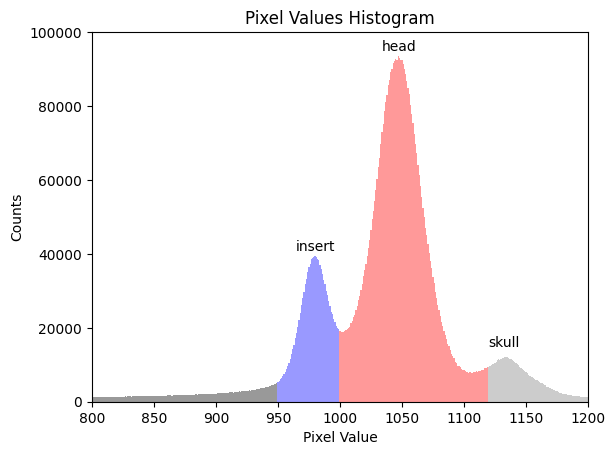

In [43]:
hist, bin_edges = np.histogram(volume.flatten(), bins = np.max(volume))
plt.bar(bin_edges[:-1][:950], hist[:950], width = 1.01, color = 'black', alpha = 0.4)
plt.bar(bin_edges[:-1][950:1000], hist[950:1000], width = 1.01, color = 'blue', alpha = 0.4)
plt.bar(bin_edges[:-1][1000:1120], hist[1000:1120], width = 1.01, color = 'red', alpha = 0.4)
plt.bar(bin_edges[:-1][1120:], hist[1120:], width = 1.01, color = 'gray', alpha = 0.4)
plt.text(980, 42000, 'insert', fontsize = 10, ha = 'center', va = 'center')
plt.text(1048, 96000, 'head', fontsize = 10, ha = 'center', va = 'center')
plt.text(1132, 16000, 'skull', fontsize = 10, ha = 'center', va = 'center')

plt.xlabel('Pixel Value')
plt.ylabel('Counts')
plt.title('Pixel Values Histogram')
plt.xlim(800, 1200)
plt.ylim(0, 100000)
plt.show()

In [2]:
import pydicom
import numpy as np
import os

folder = "zz20260319"

files = [pydicom.dcmread(os.path.join(folder, f)) for f in os.listdir(folder)]

# Sort by slice position (z)
files.sort(key=lambda x: float(x.ImagePositionPatient[2]))
positions = [float(f.ImagePositionPatient[2]) for f in files]
print(len(np.unique(positions)))
volume = np.stack([f.pixel_array for f in files])

print(volume.shape)   # (num_slices, 512, 512)
z_positions = [f.ImagePositionPatient[2] for f in files]
dz = np.abs(z_positions[1] - z_positions[0])

dx, dy = files[0].PixelSpacing
print(dx, dy, dz)

# Rotate volume
spacing = np.array([1, 0.78125, 0.78125])

axes = (0, 1)
volume = np.rot90(volume, 1, axes)
temp = spacing[axes[0]]
spacing[axes[0]] = spacing[axes[1]]
spacing[axes[1]] = temp

axes = (0, 2)
volume = np.rot90(volume, 1, axes)
temp = spacing[axes[0]]
spacing[axes[0]] = spacing[axes[1]]
spacing[axes[1]] = temp

print(volume.shape, spacing)

290
(290, 512, 512)
0.78125 0.78125 1.0
(512, 290, 512) [0.78125 1.      0.78125]


In [8]:
volume.tofile('volume.bin')

In [33]:
import pyvista as pv

regions = [[950, 1000], [1000, 1090], [1120, 1170]]
colors = [np.array([128, 128, 128, 64]), np.array([0, 0, 0, 64]), np.array([255, 255, 255, 128])]
total_mesh = None
save_path = 'source_vtps'
dim = volume.shape
print(dim, dim + np.array([1, 1, 1]))

for i, region in enumerate(regions):
    img = pv.ImageData(dimensions = dim + np.array([1, 1, 1]))
    img.spacing = spacing
    img.origin = (-dim[0] * spacing[0] / 2, -dim[1] * spacing[1] / 2, -dim[2] * spacing[2] / 2)
    img.cell_data["density"] = volume.ravel(order = "F")
    img = img.threshold(region[0], scalars = "density")
    surface = img.extract_surface()
    surface.cell_data['RGBA'] = np.array([colors[i]] * surface.n_cells, dtype=np.uint8)
    surface.save(os.path.join(save_path, f"source_{i}.vtp"))



(512, 290, 512) [513 291 513]
